In [1]:
import xarray as xr
import numpy as np

LWPERTIN = xr.open_dataset('./wrflowinp_d02')['LWPERTIN']
# Domain 1
#LWPERTIN = LWPERTIN.fillna(0)

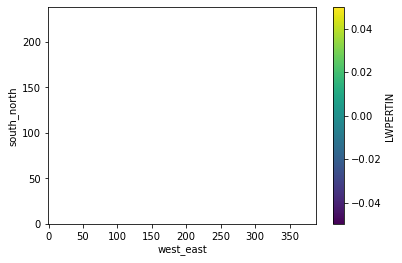

In [8]:
LWPERTIN[50][20,...].plot()

In [2]:
import pandas as pd

# Define start and end datetimes
t0 = pd.Timestamp("2013-11-01 00:00:00")
t1 = pd.Timestamp("2013-11-05 00:00:00")

# Generate 1-hr steps (end inclusive)
times_1hr = pd.date_range(start=t0, end=t1, freq="1h")
# Generate 3-min steps (end inclusive)
times_3min = pd.date_range(start=t0, end=t1, freq="15min")

# Format as WRF-style strings
times_str_3min = [t.strftime("%Y-%m-%d_%H:%M:%S") for t in times_3min]
time_str_1hr = [t.strftime("%Y-%m-%d_%H:%M:%S") for t in times_1hr]

In [3]:
from netCDF4 import Dataset
import numpy as np
from tqdm import tqdm

def make_wrflowinp_from_array(template_file, out_file, lwpertin_array, times_str):
    """
    Create wrflowinp_d0X from wrfinput_d0X template, inserting LWPERTIN.
    """
    tmpl = Dataset(template_file, "r")

    # Create new output
    nc = Dataset(out_file, "w", format="NETCDF4_CLASSIC")

    # Copy dimensions from template
    for dname, dim in tmpl.dimensions.items():
        size = len(dim) if not dim.isunlimited() else None
        # For Time we’ll set unlimited and let nt grow
        if dname == "Time":
            nc.createDimension("Time", None)
        else:
            nc.createDimension(dname, size)

    # Copy global attributes
    for att in tmpl.ncattrs():
        nc.setncattr(att, tmpl.getncattr(att))

    # Copy coordinate vars (optional)
    for vname in ["XLAT", "XLONG"]:
        if vname in tmpl.variables:
            v_in = tmpl.variables[vname]
            v_out = nc.createVariable(vname, v_in.datatype, v_in.dimensions)
            v_out.setncatts({k: v_in.getncattr(k) for k in v_in.ncattrs()})
            v_out[:] = v_in[:]

    # Define DateStrLen if missing
    if "DateStrLen" not in nc.dimensions:
        nc.createDimension("DateStrLen", 19)

    # Write Times
    nt, nz, ny, nx = lwpertin_array.shape
    times_var = nc.createVariable("Times", "S1", ("Time", "DateStrLen"))
    for it, tstamp in enumerate(times_str):
        times_var[it, :] = np.array(list(tstamp.ljust(19)), dtype="S1")

    # Write LWPERTIN
    #lwpertin = nc.createVariable(
    #    "LWPERTIN", "f4", ("Time","bottom_top","south_north","west_east"),
    #    zlib=False, fill_value=0.0, chunksizes=(1,1,ny,nx)
    #)
    lwpertin = nc.createVariable(
        "LWPERTIN", "f4", ("Time","bottom_top","south_north","west_east"),
        zlib=True, complevel=4, chunksizes=(1,1,ny,nx), fill_value=0.0
    )
    lwpertin.FieldType   = 104
    lwpertin.MemoryOrder = "XYZ"
    lwpertin.units       = ""
    lwpertin.description = "LW perturbation field"
    lwpertin.stagger     = ""

    for it in tqdm(range(nt)):
        temp = lwpertin_array[it].fillna(0)#[0,0]#.plot()
        temp = np.where(temp < 1000, temp, 0.0)
        lwpertin[it, :, :, :] = temp

    tmpl.close()
    nc.close()
    print(f"✅ wrote {out_file} with {nt} timesteps")

In [6]:
make_wrflowinp_from_array('wrfinput_d01', 'wrflowinp_d01', LWPERTIN, times_str_3min)

100%|███████████████████████████████████████| 1921/1921 [04:22<00:00,  7.33it/s]


✅ wrote wrflowinp_d01 with 1921 timesteps


In [5]:
! rm wrflowinp_d01

In [23]:
xr.open_dataset('./wrflowinp_d02')['LWPERTIN']

<xarray.DataArray 'LWPERTIN' (Time: 1921, bottom_top: 54, south_north: 740,
                              west_east: 1200)>
[92115792000 values with dtype=float32]
Coordinates:
    XLAT     (Time, south_north, west_east) float32 ...
    XLONG    (Time, south_north, west_east) float32 ...
Dimensions without coordinates: Time, bottom_top, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    units:        
    description:  LW perturbation field
    stagger: